In [53]:
import pandas as pd
import os
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score  # <-- Línea corregida
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,precision_recall_curve,auc,roc_auc_score,roc_curve,recall_score,classification_report 



In [49]:
type(y_train)


numpy.ndarray

In [ ]:

ART = "artifacts"

X_train = pd.read_csv(os.path.join(ART, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(ART, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(ART, "X_test.csv"))
y_train = pd.read_csv(os.path.join(ART, "y_train.csv"))["Class"].values
y_val   = pd.read_csv(os.path.join(ART, "y_val.csv"))["Class"].values
y_test  = pd.read_csv(os.path.join(ART, "y_test.csv"))["Class"].values

print("Train:", X_train.shape, "| balance:", np.bincount(y_train))
print("Val:  ", X_val.shape,"| balance:", np.bincount(y_val),  "| fraude:", f"{y_val.mean():.4%}")
print("Test: ", X_test.shape,"| balance:", np.bincount(y_test), "| fraude:", f"{y_test.mean():.4%}")
INPUT_DIM = X_train.shape[1]   # nº de variables = tamaño de la capa de entrada



Train: (341176, 31) | balance: [170588 170588]
Val:   (56962, 31) | balance: [56863    99] | fraude: 0.1738%
Test:  (56962, 31) | balance: [56864    98] | fraude: 0.1720%


# Estrategias de entrenamiento


## L1

In [ ]:
def printing_Kfold_scores(x_train_data, y_train_data, penalty_type='l1'):
    fold = KFold(n_splits=5, shuffle=False)

    # Different C parameters
    c_param_range = [0.01, 0.1, 1, 10, 100]

    results_table = pd.DataFrame(index=range(len(c_param_range)), columns=['C_parameter', 'Mean recall score'])
    results_table['C_parameter'] = c_param_range

    # Seleccionar el solver adecuado según la penalización
    # 'liblinear' para l1, 'lbfgs' es para l2
    chosen_solver = 'liblinear' if penalty_type == 'l1' else 'lbfgs'

    j = 0
    for c_param in c_param_range:
        print('-------------------------------------------')
        print(f'C parameter: {c_param} | Penalty: {penalty_type.upper()}')
        print('-------------------------------------------')

        recall_accs = []
        for iteration, indices in enumerate(fold.split(x_train_data), start=1):

            # 1. Aplicamos la penalización y el solver dinámicamente
            lr = LogisticRegression(C=c_param, penalty=penalty_type, solver=chosen_solver, max_iter=1000)

            # Entrenamiento
            lr.fit(x_train_data.iloc[indices[0]], y_train_data[indices[0]].ravel())

            # Predicción (Le quité el .values al final para mantener consistencia con Pandas)
            y_pred_undersample = lr.predict(x_train_data.iloc[indices[1]])

            # Calculamos Recall
            recall_acc = recall_score(y_train_data[indices[1]], y_pred_undersample)
            recall_accs.append(recall_acc)
            print('Iteration', iteration, ': recall score =', recall_acc)

        results_table.loc[j, 'Mean recall score'] = np.mean(recall_accs)
        j += 1
        print(f'\nMean recall score: {np.mean(recall_accs)}\n')

    best_c = results_table.loc[results_table['Mean recall score'].idxmax()]['C_parameter']
    
    print('*********************************************************************************')
    print(f'Best {penalty_type.upper()} modelo de cross validation es con el C = {best_c}')
    print('*********************************************************************************')
    
    return best_c

In [58]:
# Para correr tu modelo LASSO (L1)
print("=== EJECUTANDO LASSO ===")
best_c_lasso = printing_Kfold_scores(X_train, y_train, penalty_type='l1')

# Para correr tu modelo RIDGE (L2)
print("\n=== EJECUTANDO RIDGE ===")
best_c_ridge = printing_Kfold_scores(X_train, y_train, penalty_type='l2')

=== EJECUTANDO LASSO ===
-------------------------------------------
C parameter: 0.01 | Penalty: L1
-------------------------------------------
Iteration 1 : recall score = 0.9830508474576272
Iteration 2 : recall score = 0.937007874015748
Iteration 3 : recall score = 0.9403359607947332
Iteration 4 : recall score = 0.9223565618817322
Iteration 5 : recall score = 0.9240126035026013

Mean recall score: 0.9413527695304884

-------------------------------------------
C parameter: 0.1 | Penalty: L1
-------------------------------------------
Iteration 1 : recall score = 0.9830508474576272
Iteration 2 : recall score = 0.937007874015748
Iteration 3 : recall score = 0.9444100020665427
Iteration 4 : recall score = 0.9251557118780684
Iteration 5 : recall score = 0.9264746830805305

Mean recall score: 0.9432198236997035

-------------------------------------------
C parameter: 1 | Penalty: L1
-------------------------------------------
Iteration 1 : recall score = 0.9830508474576272
Iteration 2 :

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ENTRENAMOS LOS MODELOS FINALES CON EL MEJOR 'C'
# (Asumiendo que guardaste tus mejores C en estas variables)
modelo_final_l1 = LogisticRegression(C=best_c_lasso, penalty='l1', solver='liblinear')
modelo_final_l1.fit(X_train, y_train.ravel())
y_pred_l1 = modelo_final_l1.predict(X_test)

modelo_final_l2 = LogisticRegression(C=best_c_ridge, penalty='l2', solver='lbfgs', max_iter=1000)
modelo_final_l2.fit(X_train, y_train.ravel())
y_pred_l2 = modelo_final_l2.predict(X_test)

# 2. IMPRIMIMOS LAS MATRICES DE CONFUSIÓN
print("--- MATRIZ DE CONFUSIÓN: LASSO (L1) ---")
matriz_l1 = confusion_matrix(y_test, y_pred_l1)
print(matriz_l1)

print("\n--- MATRIZ DE CONFUSIÓN: RIDGE (L2) ---")
matriz_l2 = confusion_matrix(y_test, y_pred_l2)
print(matriz_l2)

--- MATRIZ DE CONFUSIÓN: LASSO (L1) ---
[[55447  1417]
 [    9    89]]

--- MATRIZ DE CONFUSIÓN: RIDGE (L2) ---
[[55471  1393]
 [    9    89]]


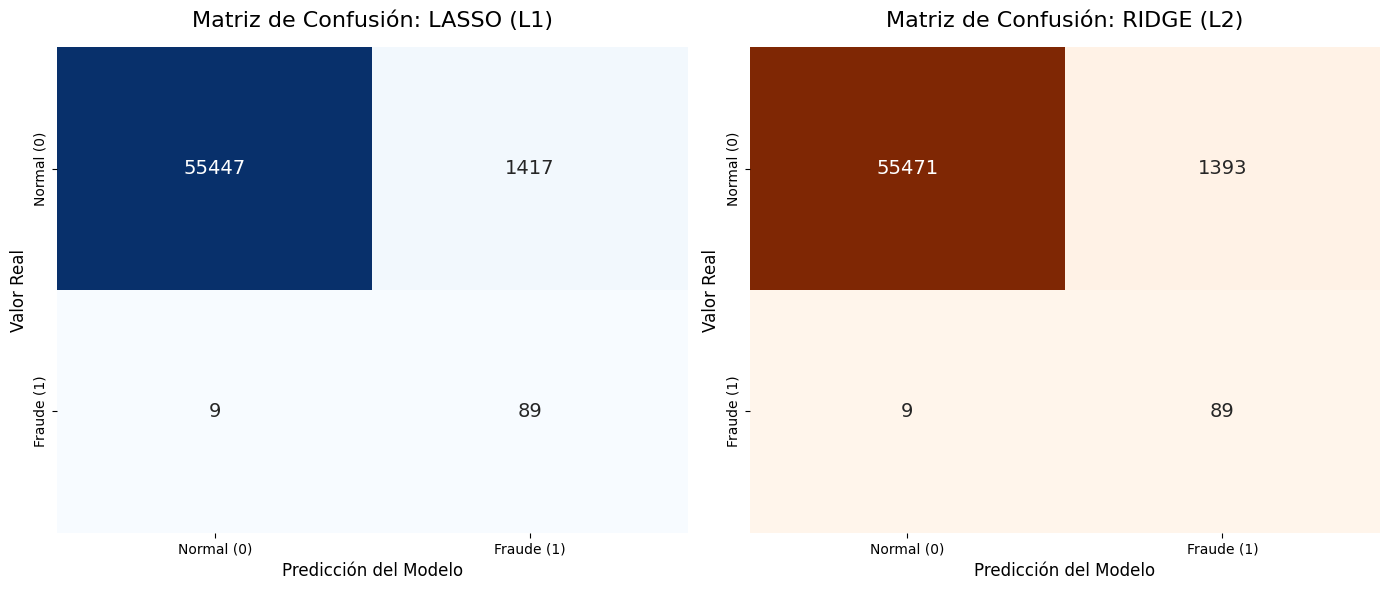

In [62]:
# 1. Configuramos el tamaño del lienzo (1 fila, 2 columnas)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Etiquetas claras para el banco
etiquetas = ['Normal (0)', 'Fraude (1)']

# --- GRÁFICO 1: LASSO (L1) ---
sns.heatmap(matriz_l1, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ax[0], annot_kws={"size": 14})
ax[0].set_title('Matriz de Confusión: LASSO (L1)', fontsize=16, pad=15)
ax[0].set_ylabel('Valor Real', fontsize=12)
ax[0].set_xlabel('Predicción del Modelo', fontsize=12)

# --- GRÁFICO 2: RIDGE (L2) ---
sns.heatmap(matriz_l2, annot=True, fmt='g', cmap='Oranges', cbar=False, 
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ax[1], annot_kws={"size": 14})
ax[1].set_title('Matriz de Confusión: RIDGE (L2)', fontsize=16, pad=15)
ax[1].set_ylabel('Valor Real', fontsize=12)
ax[1].set_xlabel('Predicción del Modelo', fontsize=12)

# Ajustamos los márgenes para que se vea estético
plt.tight_layout()
plt.show()